In [1]:
# A couple requried imports
from glob import glob 
import numpy as np
from matplotlib import pyplot as plt
import os
import urllib
import zipfile
from glob import glob

from tifffile import imread

# Importing the deep learning framework
from csbdeep.models import CARE, Config

from csbdeep.utils import plot_some, plot_history

import ssl
ssl._create_default_https_context = ssl._create_unverified_context

I0000 00:00:1758490542.346668    2351 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1758490542.383339    2351 cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1758490543.265875    2351 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [5]:
# create a folder for our data.
if not os.path.isdir('./data'):
    os.mkdir('./data')

# check if data has been downloaded already
zipPath="data/SEM.zip"

with zipfile.ZipFile(zipPath, 'r') as zip_ref:
    zip_ref.extractall("data")

In [6]:
# Load the SEM stack 
train_imgs = np.moveaxis(imread('data/SEM/train/train.tif'), 0, -1)
print(train_imgs.shape)

(2971, 1690, 7)


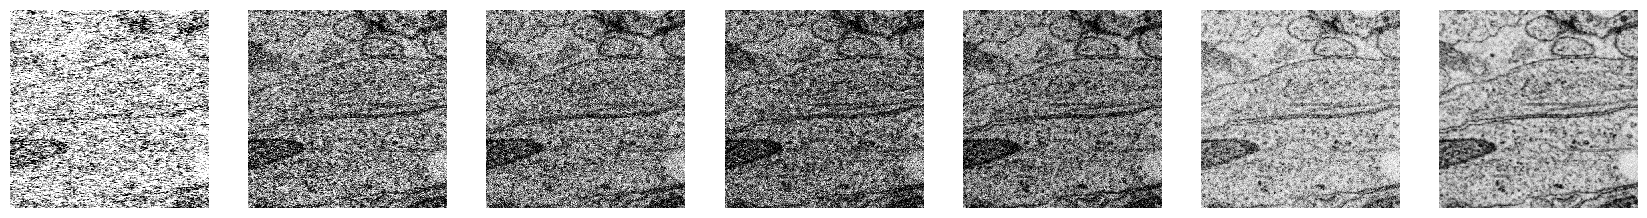

In [7]:

plt.figure(figsize=(21,3))
for i in range(train_imgs.shape[-1]):
    plt.subplot(1,7,i+1)
    plt.imshow(train_imgs[1400:1600,400:600,i], cmap='gray_r', interpolation='nearest')
    plt.axis('off')

In [8]:
def get_patches(img, shape=(128, 128)):
    patches = []
    for y in range(0, img.shape[0]-shape[0], shape[0]):
        for x in range(0, img.shape[1]-shape[1], shape[1]):
            patches.append(img[y:y+shape[0], x:x+shape[0]])
    
    return np.array(patches)

In [9]:
# Extract 128x128 patches from all seven noisy images
patches = get_patches(train_imgs)

np.random.shuffle(patches)
train_patches = patches[:270]
val_patches = patches[270:]

print(train_patches.shape)
print(val_patches.shape)

(270, 128, 128, 7)
(29, 128, 128, 7)


In [10]:
X = []
Y = []
for patch in train_patches:
    for i in range(7):
        for j in range(7):
            if i != j:
                X.append(patch[...,i])
                Y.append(patch[...,j])
                
X = np.array(X)[...,np.newaxis]
Y = np.array(Y)[...,np.newaxis]

In [11]:
X_val = []
Y_val = []
for patch in val_patches:
    for i in range(7):
        for j in range(7):
            if i != j:
                X_val.append(patch[...,i])
                Y_val.append(patch[...,j])
                
X_val = np.array(X_val)[...,np.newaxis]
Y_val = np.array(Y_val)[...,np.newaxis]

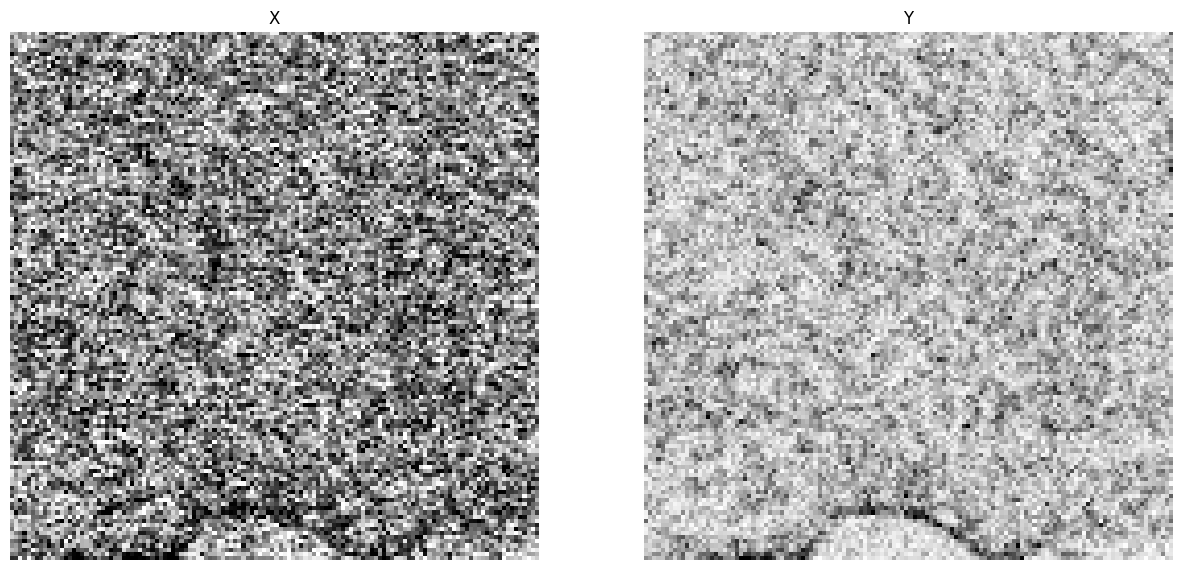

In [13]:
# Look at some patches
idx = 10
plt.figure(figsize=(15,7.5))
plt.subplot(1,2,1)
plt.imshow(X[idx,...,0], cmap='gray_r')
plt.axis('off');
plt.title('X');
plt.subplot(1,2,2)
plt.imshow(Y[idx,...,0], cmap='gray_r')
plt.axis('off');
plt.title('Y');
plt.show()

In [16]:
# note that here X,Y are every possible pair combination of the 7 noisy images is used 7*6*patches =11340
print(X.shape, Y.shape)
print(X_val.shape, Y_val.shape)


(11340, 128, 128, 1) (11340, 128, 128, 1)
(1218, 128, 128, 1) (1218, 128, 128, 1)


In [20]:
# Now we normalize the data to 0 mean and 1 standard deviation.
mean = np.mean(np.concatenate([X, Y], axis=-1))
std = np.std(np.concatenate([X, Y], axis=-1))
def normalize(data, mean, std):
    return (data - mean)/std

In [21]:
X = normalize(X, mean, std)
Y = normalize(Y, mean, std)
X_val = normalize(X_val, mean, std)
Y_val = normalize(Y_val, mean, std)

In [22]:
# Note: You want to increase train_epochs to something around 100-200.
config = Config(axes='YXC', n_channel_in=1, n_channel_out=1, train_loss='mse', unet_kern_size=3,
               train_steps_per_epoch=200, train_epochs=30)
vars(config)

{'n_dim': 2,
 'axes': 'YXC',
 'n_channel_in': 1,
 'n_channel_out': 1,
 'train_checkpoint': 'weights_best.h5',
 'train_checkpoint_last': 'weights_last.h5',
 'train_checkpoint_epoch': 'weights_now.h5',
 'probabilistic': False,
 'unet_residual': True,
 'unet_n_depth': 2,
 'unet_kern_size': 3,
 'unet_n_first': 32,
 'unet_last_activation': 'linear',
 'unet_input_shape': (None, None, 1),
 'train_loss': 'mse',
 'train_epochs': 30,
 'train_steps_per_epoch': 200,
 'train_learning_rate': 0.0004,
 'train_batch_size': 16,
 'train_tensorboard': True,
 'train_reduce_lr': {'factor': 0.5, 'patience': 10, 'min_delta': 0}}

In [23]:
# Here we create a new model, which is called exmaple_model and stored in the directory 'models'.
model = CARE(config, name='N2N_SEM', basedir='models')

W0000 00:00:1758491379.976909    2351 gpu_device.cc:2456] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1758491379.979237    2351 gpu_device.cc:2456] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1758491380.101955    2351 gpu_device.cc:2040] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 29041 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5090, pci bus id: 0000:01:00.0, compute capability: 12.0a


In [24]:
history = model.train(X, Y, (X_val, Y_val))


Epoch 1/30


I0000 00:00:1758491396.657182   10168 service.cc:158] XLA service 0x7fe0d80098c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1758491396.657205   10168 service.cc:166]   StreamExecutor device (0): NVIDIA GeForce RTX 5090, Compute Capability 12.0a
I0000 00:00:1758491396.714778   10168 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1758491396.998864   10168 cuda_dnn.cc:463] Loaded cuDNN version 91002


 14/200 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.0709 - mae: 0.8077 - mse: 1.0709

I0000 00:00:1758491400.163912   10168 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


195/200 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.8668 - mae: 0.7429 - mse: 0.8668

/opt/venv/lib/python3.11/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input
Received: inputs=('Tensor(shape=(1, 128, 128, 1))',)
  warnings.warn(msg)


200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 0.7684 - mae: 0.7073 - mse: 0.7684 - val_loss: 0.6688 - val_mae: 0.6645 - val_mse: 0.6688 - learning_rate: 4.0000e-04
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.6952 - mae: 0.6774 - mse: 0.6952 - val_loss: 0.6376 - val_mae: 0.6467 - val_mse: 0.6376 - learning_rate: 4.0000e-04
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.6717 - mae: 0.6627 - mse: 0.6717 - val_loss: 0.6856 - val_mae: 0.6875 - val_mse: 0.6856 - learning_rate: 4.0000e-04
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.6457 - mae: 0.6474 - mse: 0.6457 - val_loss: 0.5753 - val_mae: 0.6074 - val_mse: 0.5753 - learning_rate: 4.0000e-04
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.6310 - mae: 0.6375 - mse: 0.6310 - val_loss: 0.5691 - val_mae: 0.6012 - val_mse: 0.5691 - learning_rate: 4.0000e-04
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.6162 - mae: 0.6290 - mse: 0.6162 - val_loss: 0.5702 - v

['learning_rate', 'loss', 'mae', 'mse', 'val_loss', 'val_mae', 'val_mse']


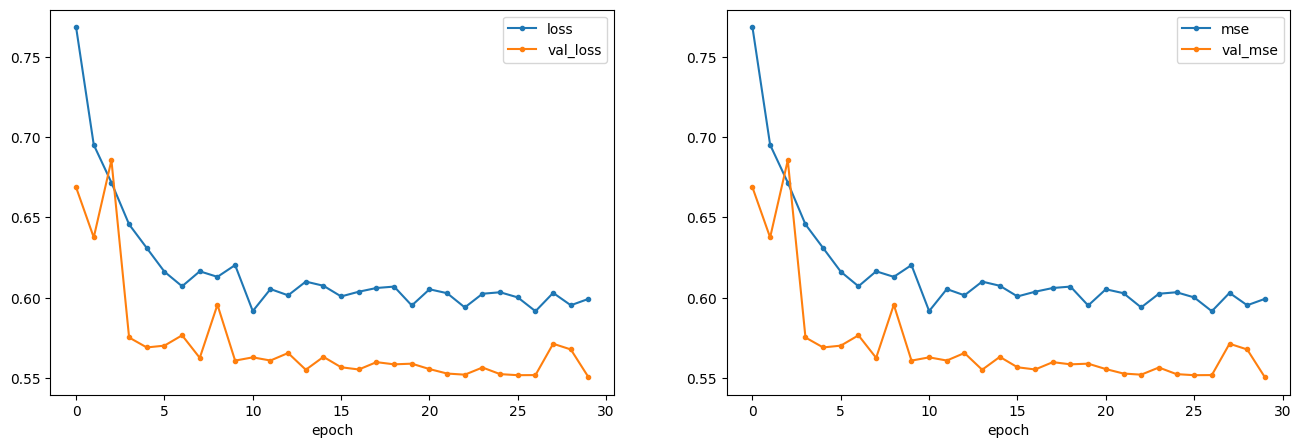

In [25]:
print(sorted(list(history.history.keys())))
plt.figure(figsize=(16,5))
plot_history(history,['loss','val_loss'],['mse','val_mse']);

In [26]:
def denormalize(img, mean, std):
    return (img * std) + mean

In [27]:
test_imgs = imread('data/SEM/test/test.tif')
print(test_imgs.shape)

(7, 2959, 1666)


In [28]:
test_denoised = []
for img in test_imgs:
    test_denoised.append(denormalize(model.predict(normalize(img, mean, std), 'YX', normalizer=None), mean, std))

E0000 00:00:1758491522.834884   10424 slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv (f32[1,2960,1668,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[1,2960,1668,32]{3,2,1,0}, f32[32,3,3,32]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"} is taking a while...
E0000 00:00:1758491522.959826   10166 slow_operation_alarm.cc:140] The operation took 1.125099961s
Trying algorithm eng0{} for conv (f32[1,2960,1668,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[1,2960,1668,32]{3,2,1,0}, f32[32,3,3,32]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBiasActivationForwa

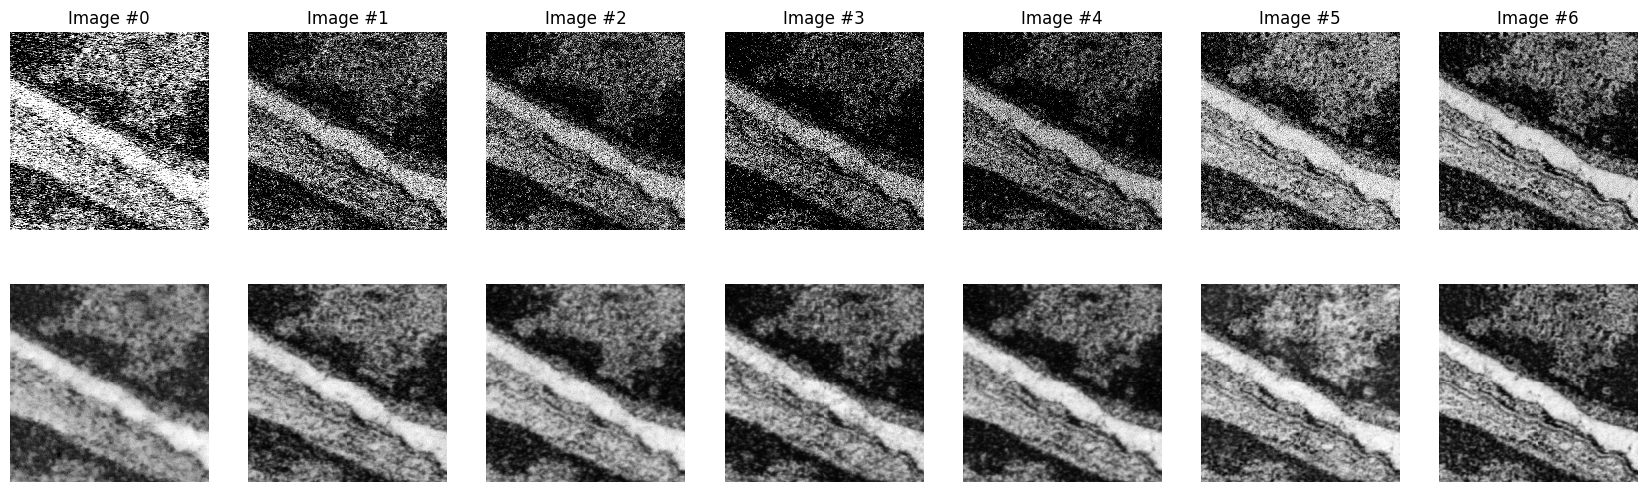

In [29]:
plt.figure(figsize=(21,6))
for i in range(train_imgs.shape[-1]):
    plt.subplot(2,7,i+1)
    plt.imshow(test_imgs[i][1400:1600,400:600], cmap='gray_r', interpolation='nearest')
    plt.axis('off')
    plt.title('Image #{}'.format(i));
for i in range(train_imgs.shape[-1]):
    plt.subplot(2,7,i+8)
    plt.imshow(test_denoised[i][1400:1600,400:600], cmap='gray_r', interpolation='nearest')
    plt.axis('off')

In [30]:
# We can create a ground truth (GT) image by averaging over all noisy images
# But keep in mind, that this GT is still 'noisy'.
gt = np.mean(test_imgs, axis=0)

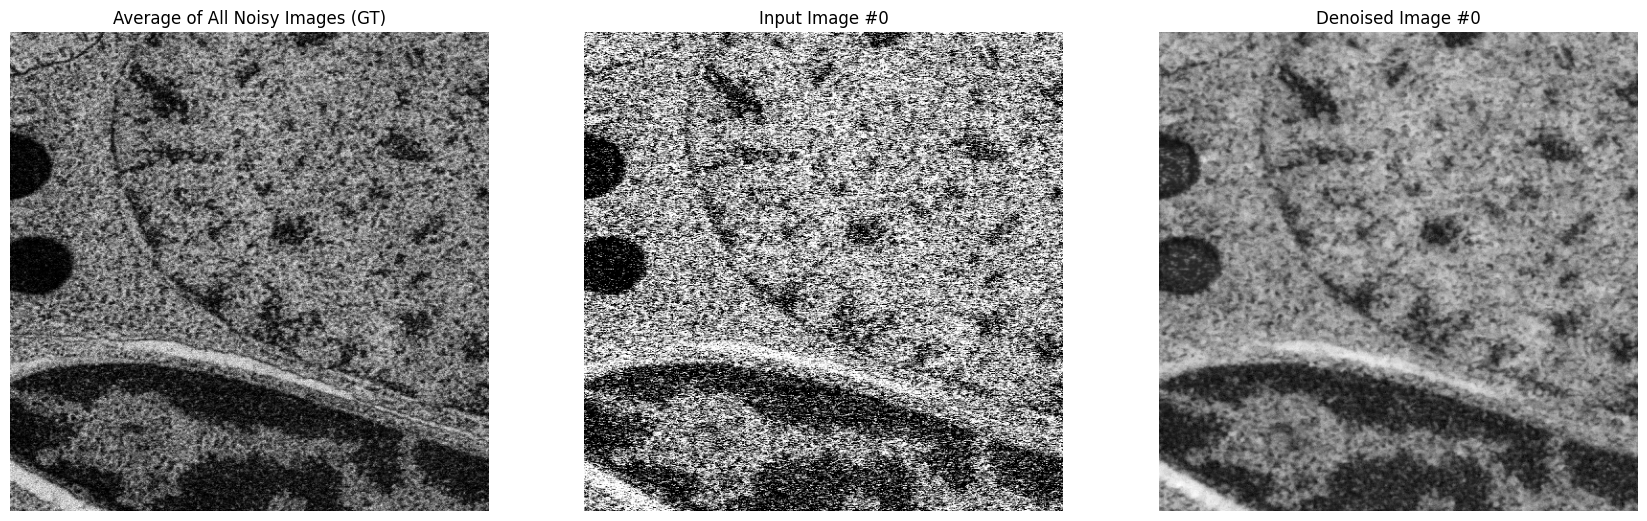

In [31]:
idx=0
plt.figure(figsize=(21,7))
plt.subplot(1,3,1)
plt.imshow(gt[1000:1500,400:900], cmap='gray_r')
plt.axis('off');
plt.title('Average of All Noisy Images (GT)')
plt.subplot(1,3,2)
plt.imshow(test_imgs[idx][1000:1500,400:900], cmap='gray_r')
plt.axis('off');
plt.title('Input Image #{}'.format(idx));
plt.subplot(1,3,3)
plt.imshow(test_denoised[idx][1000:1500,400:900], cmap='gray_r')
plt.axis('off');
plt.title('Denoised Image #{}'.format(idx));

In [32]:

def PSNR(gt, img):
    mse = np.mean((gt - img)**2)
    r = np.max(gt) - np.min(gt)
    return 20*np.log10(r) - 10*np.log10(mse)

In [33]:

# With a GT image we can compute PSNR values. 
for i in range(test_imgs.shape[0]):
    psnr_input = PSNR(gt, test_imgs[i])
    psnr_denoised = PSNR(gt, test_denoised[i])
    
    print('PSNR Input: {}; PSNR Denoised: {}'.format(np.round(psnr_input,2), np.round(psnr_denoised,2)))

PSNR Input: 10.020000457763672; PSNR Denoised: 18.6200008392334
PSNR Input: 12.949999809265137; PSNR Denoised: 18.68000030517578
PSNR Input: 13.460000038146973; PSNR Denoised: 18.40999984741211
PSNR Input: 12.539999961853027; PSNR Denoised: 19.81999969482422
PSNR Input: 13.760000228881836; PSNR Denoised: 20.110000610351562
PSNR Input: 14.649999618530273; PSNR Denoised: 20.549999237060547
PSNR Input: 18.489999771118164; PSNR Denoised: 21.350000381469727
